In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer


train = pd.read_csv("/kaggle/input/playground-series-s5e7/train.csv")
test = pd.read_csv("/kaggle/input/playground-series-s5e7/test.csv")

In [2]:
train.head(5)

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,id,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert
1,1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert
2,2,6.0,Yes,1.0,0.0,NaN,3.0,0.0,Introvert
3,3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert
4,4,1.0,No,4.0,4.0,No,13.0,NaN,Extrovert


🧱 Feature Breakdown
| Column Name                 | Type                        | Example Value       | Description / Inference                         |
| --------------------------- | --------------------------- | ------------------- | ----------------------------------------------- |
| `id`                        | Integer                     | 0, 1, 2             | Row identifier — not useful for training        |
| `Time_spent_Alone`          | Float                       | 0.0, 1.0, 6.0       | Likely hours or a scale                         |
| `Stage_fear`                | Categorical (Yes/No)        | Yes, No             | Binary categorical                              |
| `Social_event_attendance`   | Float                       | 1.0–7.0?            | Possibly count or frequency scale               |
| `Going_outside`             | Float                       | 0.0–4.0             | May be ordinal (scale of interest in going out) |
| `Drained_after_socializing` | Categorical (Yes/No or NaN) | Yes, No             | Binary categorical, **has missing values**      |
| `Friends_circle_size`       | Float                       | 3.0–15.0            | Numeric, **has missing values**                 |
| `Post_frequency`            | Float                       | 0.0–8.0             | Numeric — likely how often someone posts online |
| `Personality`               | Target                      | Introvert/Extrovert | Classification target                           |

In [3]:
train.shape

(18524, 9)

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18524 entries, 0 to 18523
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         18524 non-null  int64  
 1   Time_spent_Alone           17334 non-null  float64
 2   Stage_fear                 16631 non-null  object 
 3   Social_event_attendance    17344 non-null  float64
 4   Going_outside              17058 non-null  float64
 5   Drained_after_socializing  17375 non-null  object 
 6   Friends_circle_size        17470 non-null  float64
 7   Post_frequency             17260 non-null  float64
 8   Personality                18524 non-null  object 
dtypes: float64(5), int64(1), object(3)
memory usage: 1.3+ MB


In [5]:
train.describe()

,id,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,18524.000000,17334.000000,17344.000000,17058.000000,17470.000000,17260.000000
mean,9261.500000,3.137764,5.265106,4.044319,7.996737,4.982097
std,5347.562529,3.003786,2.753359,2.062580,4.223484,2.879139
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4630.750000,1.000000,3.000000,3.000000,5.000000,3.000000
50%,9261.500000,2.000000,5.000000,4.000000,8.000000,5.000000
75%,13892.250000,4.000000,8.000000,6.000000,12.000000,7.000000
max,18523.000000,11.000000,10.000000,7.000000,15.000000,10.000000


In [6]:
print(train['Stage_fear'].value_counts(dropna=False))
print(train['Drained_after_socializing'].value_counts(dropna=False))
print(train['Personality'].value_counts())

Stage_fear
No     12609
Yes     4022
NaN     1893
Name: count, dtype: int64
Drained_after_socializing
No     13313
Yes     4062
NaN     1149
Name: count, dtype: int64
Personality
Extrovert    13699
Introvert     4825
Name: count, dtype: int64


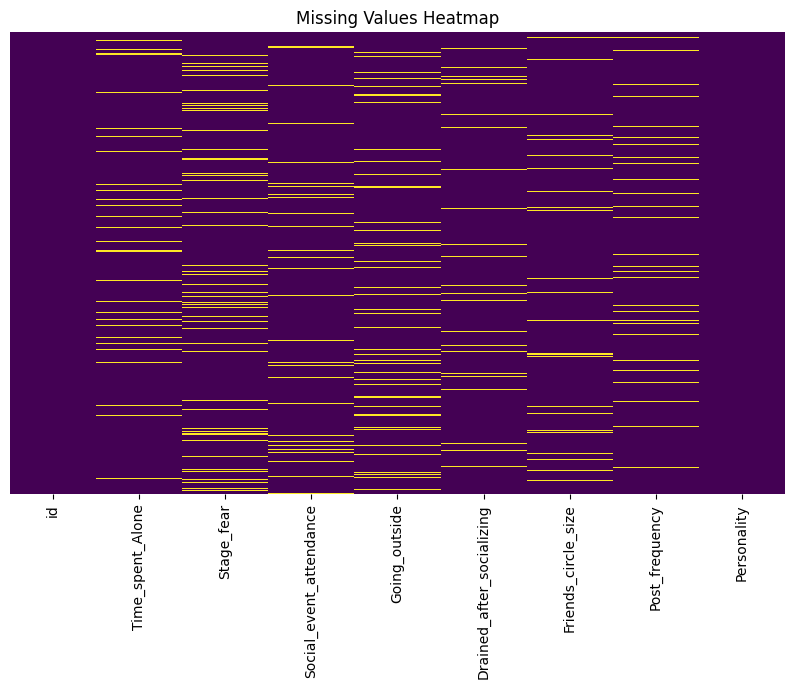

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(train.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Missing Values Heatmap")
plt.show()

## Analyze Missingness vs Personality (Target)

In [8]:
import pandas as pd

# Copy to avoid modifying original
data = train.copy()

# Add missing indicator columns
data['missing_Stage_fear'] = data['Stage_fear'].isna()
data['missing_Drained_after_socializing'] = data['Drained_after_socializing'].isna()
data['missing_Post_frequency'] = data['Post_frequency'].isna()
data['missing_Friends_circle_size'] = data['Friends_circle_size'].isna()

# Group by Personality and show % missing
missing_by_personality = data.groupby('Personality')[
    ['missing_Stage_fear', 'missing_Drained_after_socializing', 'missing_Post_frequency', 'missing_Friends_circle_size']
].mean().T * 100

print(missing_by_personality)

Personality                        Extrovert  Introvert
missing_Stage_fear                  8.387474  15.419689
missing_Drained_after_socializing   3.372509  14.238342
missing_Post_frequency              5.671947  10.093264
missing_Friends_circle_size         5.109862   7.336788


### Interpretation of Missingness vs Personality

| Feature                     | Missing % (Extroverts) | Missing % (Introverts) | Difference | Interpretation                                                            |
| --------------------------- | ---------------------- | ---------------------- | ---------- | ------------------------------------------------------------------------- |
| `Stage_fear`                | **8.39%**              | **15.42%**             | +7.0%      | Introverts are \~2x more likely to skip this — possibly due to discomfort |
| `Drained_after_socializing` | **3.37%**              | **14.24%**             | +10.9%     | Strongest signal — introverts **actively avoid** this question            |
| `Post_frequency`            | **5.67%**              | **10.09%**             | +4.4%      | Introverts may avoid digital expression too                               |
| `Friends_circle_size`       | **5.11%**              | **7.34%**              | +2.2%      | Weaker, but still higher among introverts                                 |


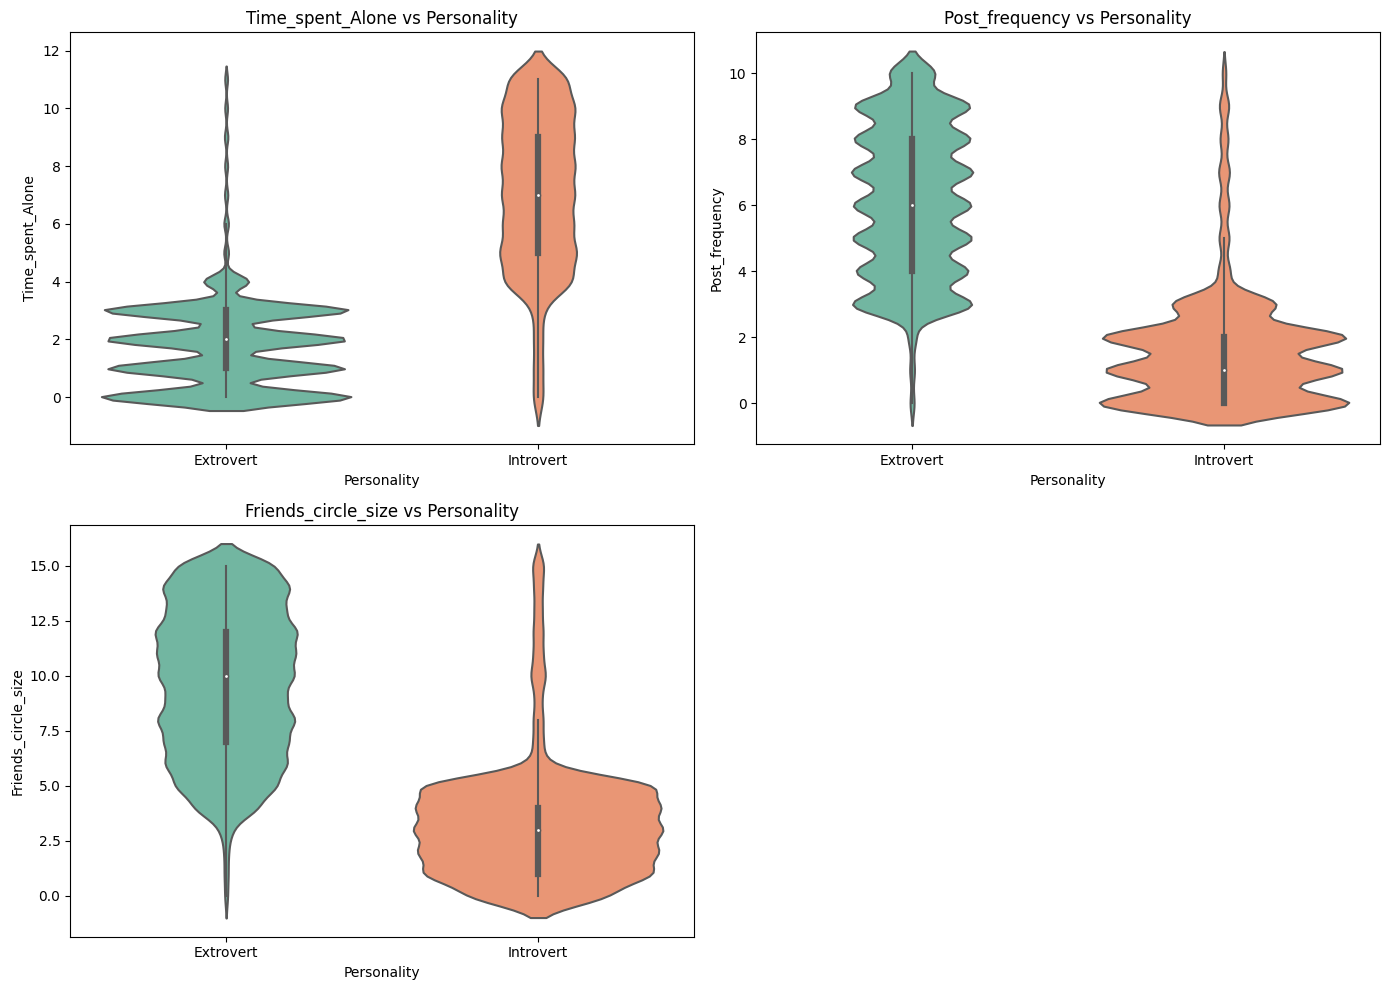

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

features = ['Time_spent_Alone', 'Post_frequency', 'Friends_circle_size']
for i, col in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.violinplot(x='Personality', y=col, data=train, palette='Set2')
    plt.title(f'{col} vs Personality')

plt.tight_layout()
plt.show()

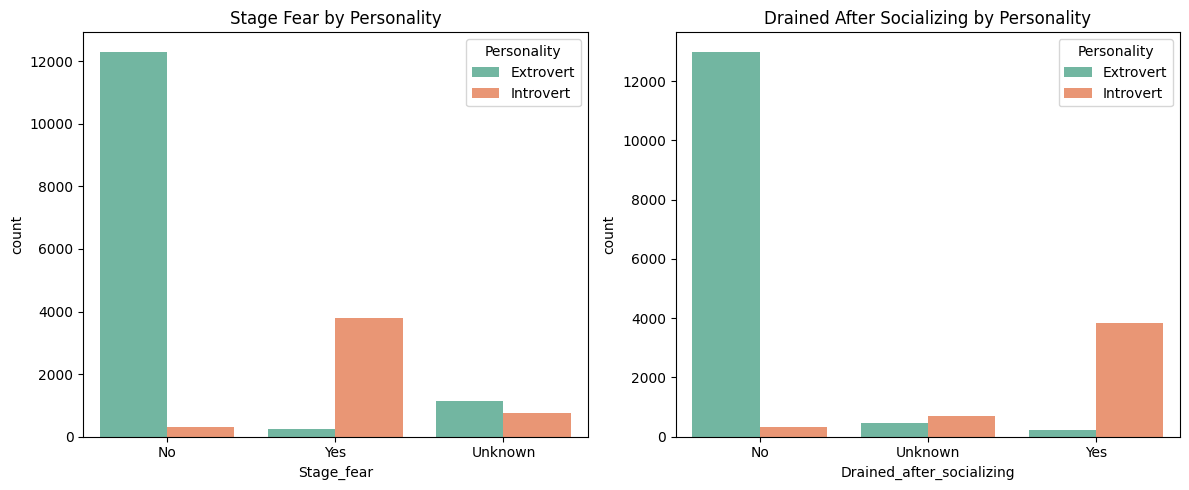

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Fill NaNs for visualization
cat_plot_data = train.copy()
cat_plot_data['Stage_fear'] = cat_plot_data['Stage_fear'].fillna('Unknown')
cat_plot_data['Drained_after_socializing'] = cat_plot_data['Drained_after_socializing'].fillna('Unknown')

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=cat_plot_data, x='Stage_fear', hue='Personality', palette='Set2')
plt.title('Stage Fear by Personality')

plt.subplot(1, 2, 2)
sns.countplot(data=cat_plot_data, x='Drained_after_socializing', hue='Personality', palette='Set2')
plt.title('Drained After Socializing by Personality')

plt.tight_layout()
plt.show()

### Domain-Aware Data Preprocessing & Feature Engineering Plan

In [11]:
target_map = {'Extrovert': 0, 'Introvert': 1}

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Copy original
df = train.copy()

# Drop ID
df.drop(columns=['id'], inplace=True)

# Add missingness indicators
for col in ['Friends_circle_size', 'Post_frequency']:
    df[f'is_missing_{col}'] = df[col].isna().astype(int)
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical NaNs with 'Unknown'
df['Stage_fear'] = df['Stage_fear'].fillna('Unknown')
df['Drained_after_socializing'] = df['Drained_after_socializing'].fillna('Unknown')

# Map categorical to numerical (preserving "Unknown" as -1)
map_bin = {'No': 0, 'Yes': 1, 'Unknown': -1}
df['Stage_fear'] = df['Stage_fear'].map(map_bin)
df['Drained_after_socializing'] = df['Drained_after_socializing'].map(map_bin)

# Encode target
df['Personality'] = df['Personality'].map({'Extrovert': 0, 'Introvert': 1})

# Separate features and target
X = df.drop(columns='Personality')
y = df['Personality']

# Optional: Train-test split
X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

/tmp/ipykernel_19/3802743352.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_19/3802743352.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [13]:
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Initialize the model
model = LGBMClassifier(
    objective='binary',
    n_estimators=200,
    random_state=42
)

# Fit using proper callbacks
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='logloss',
    callbacks=[
        early_stopping(stopping_rounds=20),
        log_evaluation(period=20)
    ]
)

# Predict on validation set
y_pred_prob = model.predict_proba(X_val)[:, 1]
y_pred = model.predict(X_val)

# Evaluate
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))
print("\nROC AUC Score:", roc_auc_score(y_val, y_pred_prob))

[LightGBM] [Info] Number of positive: 3860, number of negative: 10959
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002438 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 71
[LightGBM] [Info] Number of data points in the train set: 14819, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.260476 -> initscore=-1.043494
[LightGBM] [Info] Start training from score -1.043494
Training until validation scores don't improve for 20 rounds
[20]	valid_0's binary_logloss: 0.143323
[40]	valid_0's binary_logloss: 0.121795
[60]	valid_0's binary_logloss: 0.121595
Early stopping, best iteration is:
[44]	valid_0's binary_logloss: 0.121123
Confusion Matrix:
 [[2685   55]
 [  49  916]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      2740
          

### Feature Importance Visualization

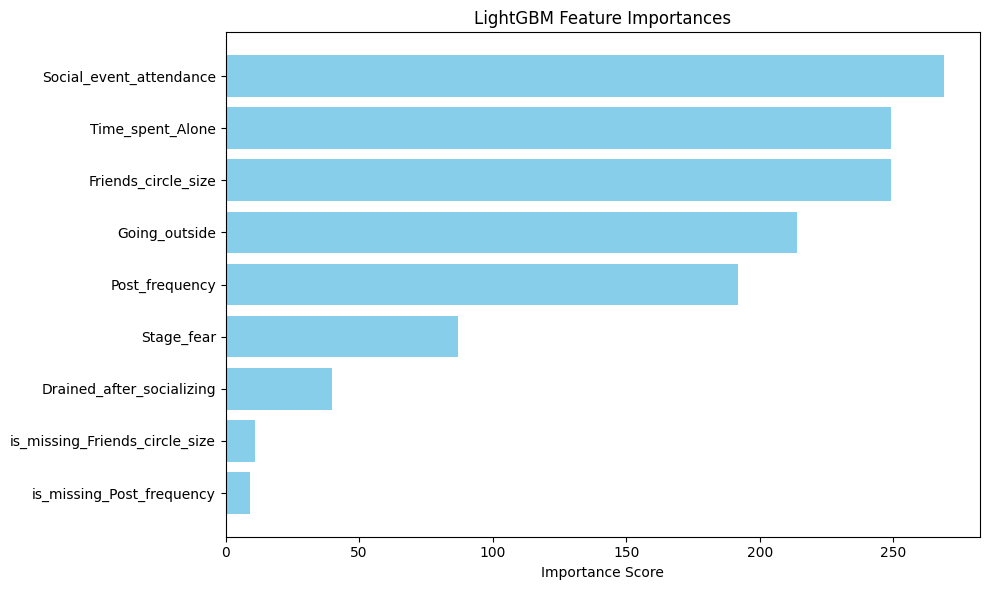

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Get importance values
importance_df = pd.DataFrame({
    'Feature': model.feature_name_,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.title('LightGBM Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

| Rank | Feature                         | Importance Score | Interpretation                                            |
| ---- | ------------------------------- | ---------------- | --------------------------------------------------------- |
| 1️⃣  | **Social\_event\_attendance**   | **270+**         | Core behavior difference — extroverts attend more events. |
| 2️⃣  | **Time\_spent\_Alone**          | High             | Introverts spend more time alone — very predictive.       |
| 3️⃣  | **Friends\_circle\_size**       | High             | Extroverts tend to have larger circles — consistent.      |
| 4️⃣  | **Going\_outside**              | Moderate-high    | Behavioral energy cue — aligns well with personality.     |
| 5️⃣  | **Post\_frequency**             | Moderate         | Social media engagement — extroverts tend to post more.   |
| 6️⃣  | **Stage\_fear**                 | Lower            | Still informative, but not as frequent as others.         |
| 7️⃣  | **Drained\_after\_socializing** | Low              | Unexpected — maybe overlaps with stronger signals.        |
| 8️⃣  | `is_missing_*` flags            | Very Low         | As expected — not primary drivers, but help fill context. |


In [15]:
# Load test set
test_id = test['id'].copy()
test.drop(columns=['id'], inplace=True)

# Impute numeric features using training medians + add flags
for col in ['Friends_circle_size', 'Post_frequency']:
    test[f'is_missing_{col}'] = test[col].isna().astype(int)
    test[col].fillna(X_train[col].median(), inplace=True)

# Categorical: fill missing with 'Unknown' and map
map_bin = {'No': 0, 'Yes': 1, 'Unknown': -1}
test['Stage_fear'] = test['Stage_fear'].fillna('Unknown').map(map_bin)
test['Drained_after_socializing'] = test['Drained_after_socializing'].fillna('Unknown').map(map_bin)

# Predict using trained model
test_pred_int = model.predict(test)

# Convert numeric predictions back to labels
test_pred_label = pd.Series(test_pred_int).map({0: 'Extrovert', 1: 'Introvert'})

# Prepare submission DataFrame
submission = pd.DataFrame({
    'id': test_id,
    'Personality': test_pred_label
})

# Save to CSV
submission.to_csv('submission.csv', index=False)
print("✅ Submission file 'submission.csv' created successfully!")

✅ Submission file 'submission.csv' created successfully!


/tmp/ipykernel_19/3914655318.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test[col].fillna(X_train[col].median(), inplace=True)
/tmp/ipykernel_19/3914655318.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try